# ANÁLISIS EXPLORATORIO DE DATOS EN EL CONJUNTO DE DATOS CLÍNICO **MEDTRINITY**

In [49]:
def show_discarded_images(ds,ds_filtered):
    print(f"{ds.num_rows-ds_filtered.num_rows} images were discarded")
    print(f"The dataset retains {ds_filtered.num_rows} images")

In [ ]:
from datasets import load_from_disk, DatasetDict
import os


dataset_version="25M_demo"

BASE_PATH=f"data/{dataset_version}"
train_ds = load_from_disk(os.path.join(BASE_PATH, "train"))
validation_ds=load_from_disk(os.path.join(BASE_PATH, "validation"))

KeyboardInterrupt: 

## Análisis del tipo de imagen médica tomada

Se quiere estudiar el número de imagenes MRI hay en el dataset, puesto que esta son las únicas que nos interesa. Para un primer análisis, filtramos el conjunto de datos quedándonos solamente con aquellas pares imágenes-descripción cuya descripción contenga la palabra clave: *MRI*.

In [60]:
def filterMRI(example, keywords=["mri", "t1", "t2", "flair", "magnetic resonance"]):
    import re
    #Extraer solo el texto antes de la primera coma porque es donde se indica el tipo de imagen que es
    caption_full = example["caption"].lower()
    caption_main = caption_full.split(',', 1)[0]
    
    # EXCLUSIÓN: Si aparece "ct" o "computed tomography" como palabra exacta, lo descartamos
    forbidden_pattern = r'\b(ct|computed tomography|ct2)\b'
    if re.search(forbidden_pattern, caption_main):
        return False
    
    # 3. INCLUSIÓN: Buscamos tus palabras clave como palabras exactas
    for word in keywords:
        # \b asegura que "t2" no coincida con "ct2"
        pattern = rf"\b{word}\b"
        if re.search(pattern, caption_main):
            return True
            
    return False


In [61]:

train_ds_mri=train_ds.filter(filterMRI,num_proc=4)

Filter (num_proc=4):   0%|          | 0/145467 [00:00<?, ? examples/s]

In [62]:
show_discarded_images(train_ds,train_ds_mri)

145445 images were discarded
The dataset retains 22 images


In [63]:
for example in train_ds.shuffle().select(range(10)):
   print((example["caption"].split(',',1)[0]))

The image is a transverse section of a brain CT scan
The image is a CT scan of the brain
The image is a CT scan of the brain
The image is a non-contrast computed tomography (CT) scan of the brain
The image is a computed tomography (CT) scan of the brain
The image is a non-contrast computed tomography (CT) scan of the brain
The image is a non-contrasted computed tomography (CT) scan of the brain
The image is a non-contrasted computed tomography (CT) scan of the brain
The image is a non-contrasted computed tomography (CT) scan of the brain
This CT scan of the brain shows a region of interest located centrally and in the upper-middle area


In [64]:
for example in train_ds_mri:
   print((example["caption"].split(',',1)[0]))

The image is a transverse slice of a brain MRI scan
The image is a magnetic resonance imaging (MRI) scan of the brain
The image is a magnetic resonance imaging (MRI) scan of the brain
The image is a transverse slice of a brain MRI scan
The image is a magnetic resonance imaging (MRI) scan of the brain
The image is a transverse slice of a brain MRI
The image is a transverse slice of a brain MRI scan
The image is a transverse slice of a brain MRI scan
The image is a transverse slice of a brain MRI scan
The image is a magnetic resonance imaging (MRI) scan of the brain
The image is a magnetic resonance imaging (MRI) scan of the brain
The image is a magnetic resonance imaging (MRI) scan of the brain
The image is a transverse section of a brain MRI scan
The image is a transverse slice of a brain MRI scan
The image is a magnetic resonance imaging (MRI) scan of the brain
The image is a transverse slice of a brain MRI scan
The image is a transverse slice of a brain MRI scan
The image is a transv

Se observan que siguen quedando datos erróneos (CTs)

## Comprobación cualitativa de las imágenes

Se comprueba la calidad de las imágnes MRI

In [ ]:
imgs=[image for image in train_ds_mri["image"]  ]
imgs_size=len(imgs)

22

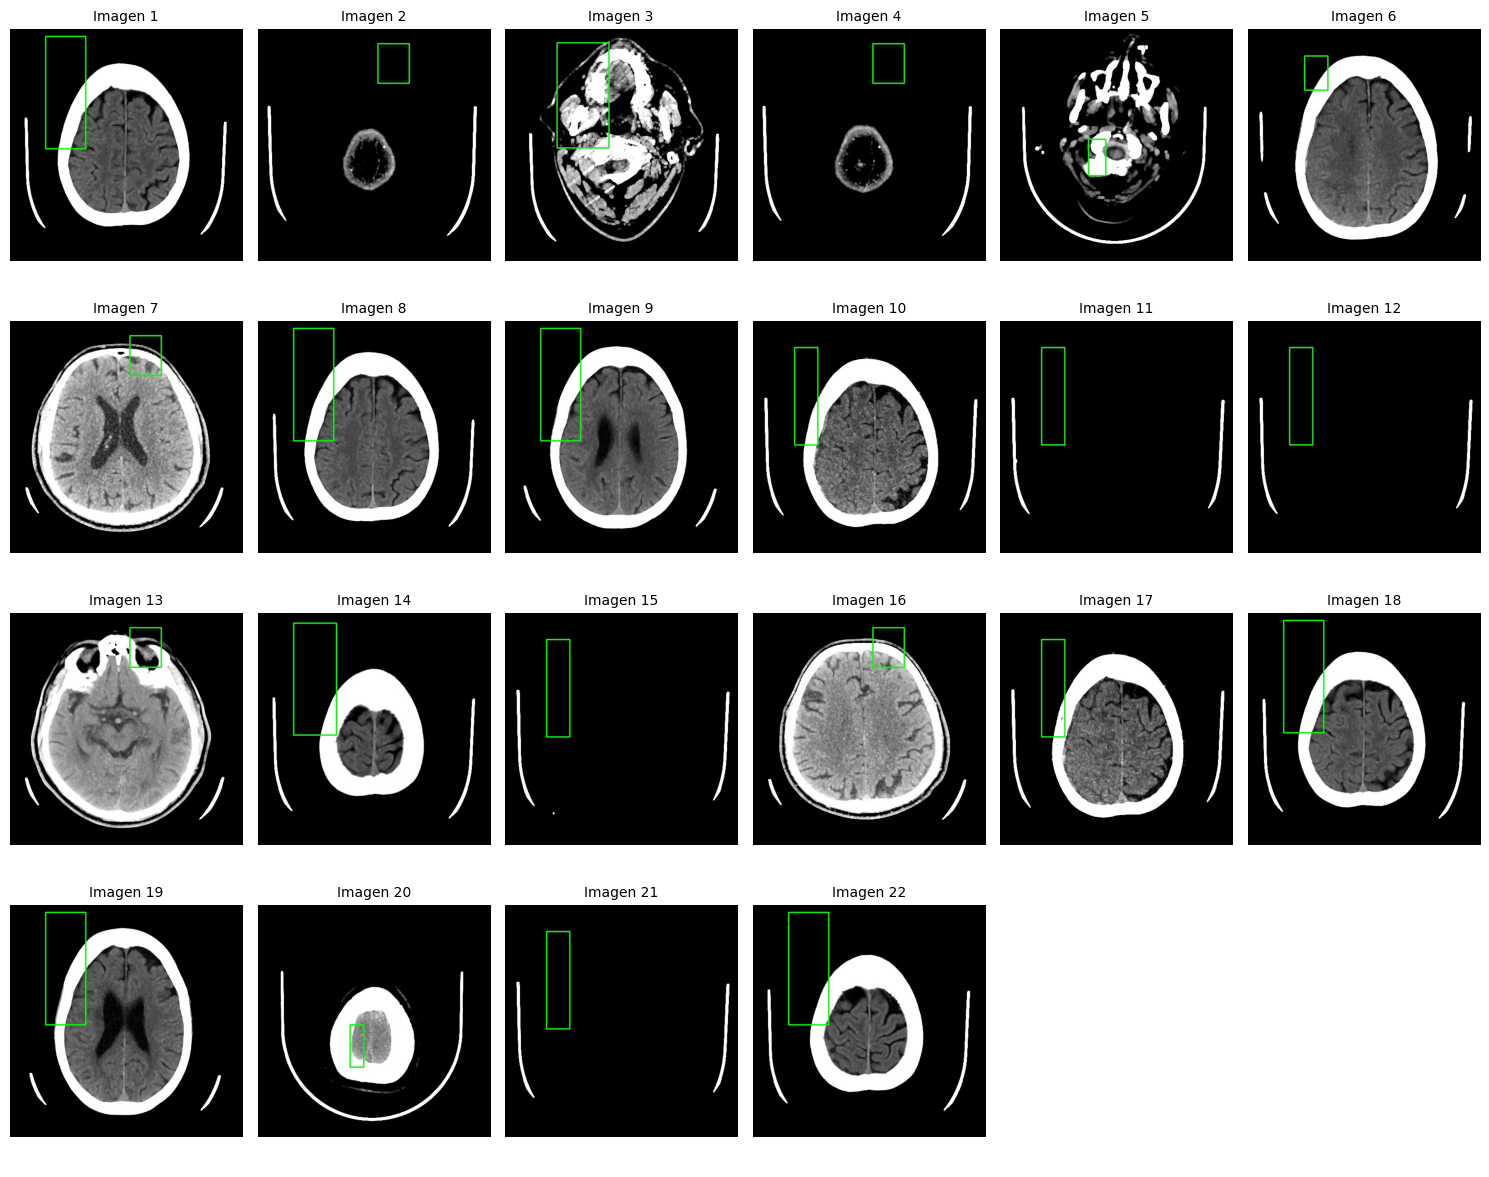

In [73]:
import math
import matplotlib.pyplot as plt
def mostrar_grid_mri(lista_imgs, cols=6):
    # Calcular filas necesarias (para 22 imágenes y 6 columnas, serán 4 filas)
    n_imgs = len(lista_imgs)
    rows = math.ceil(n_imgs / cols)
    
    # Crear la figura y la malla de subplots
    fig, axes = plt.subplots(rows, cols, figsize=(15, 3 * rows))
    
    # .flatten() convierte la matriz de axes [[ax1, ax2...], [axN...]] en una lista simple
    axes = axes.flatten()
    
    for i in range(len(axes)):
        if i < n_imgs:
            # Mostrar la imagen PIL
            axes[i].imshow(lista_imgs[i])
            axes[i].set_title(f"Imagen {i+1}", fontsize=10)
        
        # Ocultar los ejes (los números de los píxeles) para que se vea limpio
        axes[i].axis('off')
    
    plt.savefig("mri_grid")
    plt.tight_layout()
    plt.show()
    
mostrar_grid_mri(imgs)

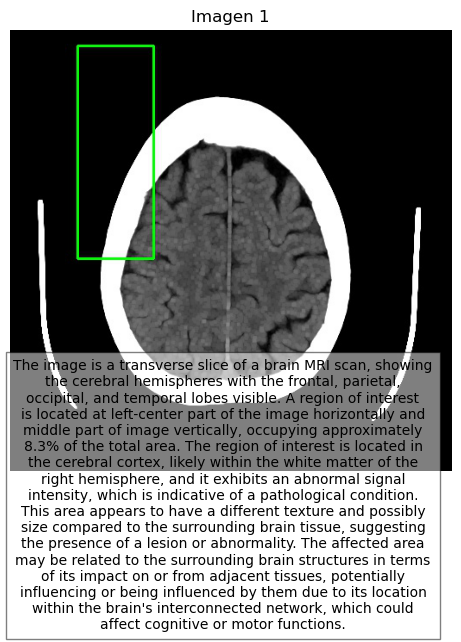

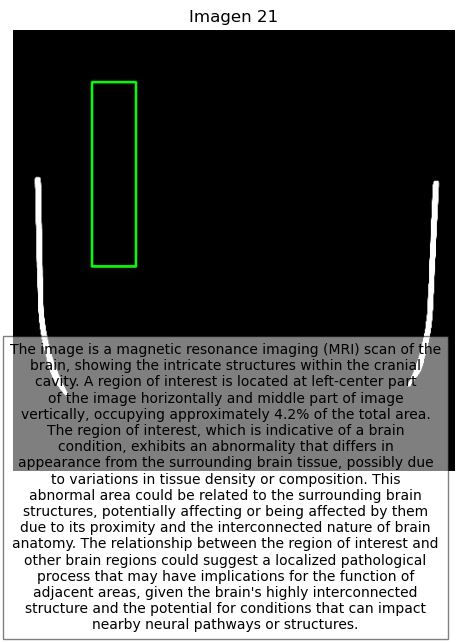

In [87]:
import textwrap
def mostrar_con_descripcion(img, caption, output_name,n_img):
    # 1. Configurar la figura. Hacemos la figura un poco más alta para que quepa el texto
    fig, ax = plt.subplots(figsize=(6, 7)) 
    
    #Mostrar la imagen
   
    ax.imshow(img)
    ax.axis('off') 
    ax.set_title(f"Imagen {n_img}", fontsize=12) 
    
    # 3. Preparar el texto largo (Wrapping)
    # Esto corta el texto cada 50 caracteres y añade saltos de línea (\n)
    texto_ajustado = "\n".join(textwrap.wrap(caption, width=60))
    
    # 4. Añadir el texto a la figura
    # (0.5, 0.02) son las coordenadas X e Y relativas (0 a 1). 
    # 0.02 está muy cerca del borde inferior.
    plt.figtext(0.5, 0.02, texto_ajustado, ha="center", va="bottom", fontsize=10, 
                bbox={"facecolor":"white", "alpha":0.5, "pad":5})
    
    # 5. Ajustar márgenes
    # Importante: dejamos espacio abajo (bottom=0.2) para que el texto no se corte
    plt.subplots_adjust(bottom=0.25)
    
    # Guardar y mostrar
    plt.savefig(output_name, dpi=300)
    plt.show()

idx_imgs = (0, 20)


capt_imgs = [train_ds_mri[int(i)]["caption"] for i in idx_imgs]

output_names = [f"mri_{i+1}_con_descripcion.png" for i in idx_imgs]


for i, idx in enumerate(idx_imgs):
    mostrar_con_descripcion(
        imgs[idx],           # imagen
        capt_imgs[i],        # caption
        output_names[i],     # nombre_archivo_salida
        idx + 1             
    )